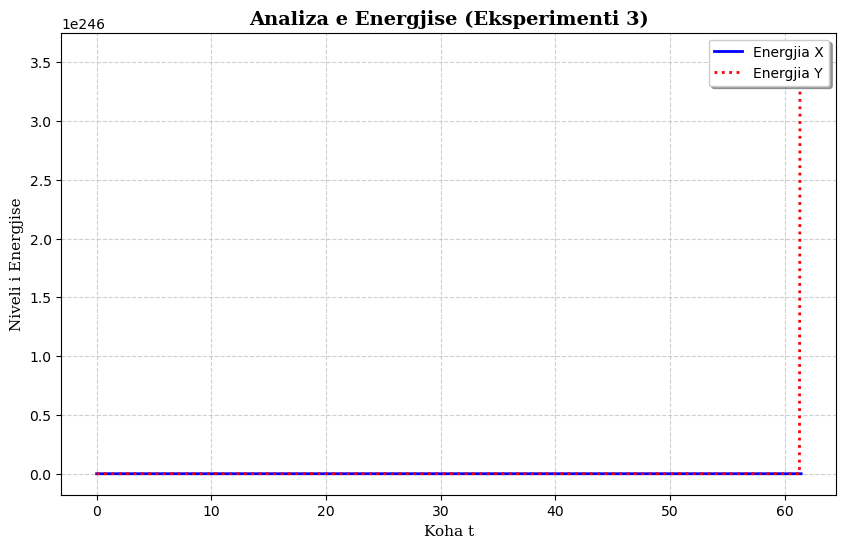

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Krijo folderin nëse nuk ekziston
if not os.path.exists('figures'):
    os.makedirs('figures')

# Sistemi i ekuacioneve diferenciale
def equations(s, t, w2x, w2y, eps, alpha):
    x, vx, y, vy = s
    dvx = -w2x * x - eps * (x - y) - alpha * x**3
    dvy = -w2y * y - eps * (y - x) - alpha * y**3
    return [vx, dvx, vy, dvy]

# Koha
t = np.linspace(0, 100, 2000)
dt = t[1] - t[0]

# Kushtet fillestare
s = [1.0, 1.0, 0.0, 0.0]

# Parametrat (w2x, w2y, eps, alpha)
params = (1.0, 1.0, 0.1, 0.05)

# Integrimi numerik (Euler i thjeshtë)
data = [s]

for _ in range(len(t) - 1):
    d = equations(data[-1], 0, *params)
    data.append([data[-1][i] + d[i] * dt for i in range(4)])

data = np.array(data)

# Energjitë
Ex = 0.5 * data[:, 1]**2 + 0.5 * params[0] * data[:, 0]**2 + 0.25 * params[3] * data[:, 0]**4
Ey = 0.5 * data[:, 3]**2 + 0.5 * params[1] * data[:, 2]**2 + 0.25 * params[3] * data[:, 2]**4

# Grafiku
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(t, Ex, label="Energjia X", color='blue', linewidth=2)
plt.plot(t, Ey, label="Energjia Y", color='red', linewidth=2, linestyle=':')

plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Analiza e Energjise (Eksperimenti 3)', fontsize=14, fontweight='bold', family='serif')
plt.xlabel('Koha t', fontsize=11, family='serif')
plt.ylabel('Niveli i Energjise', fontsize=11, family='serif')
plt.legend(loc='upper right', frameon=True, shadow=True)

plt.savefig('figures/eksperimenti_3.png')
plt.show()